In [978]:
# import numpy as np
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import re
import fnmatch
import matplotlib.pyplot as plt
from functools import reduce
from bs4 import BeautifulSoup
import requests
import osmnx as ox
from API_KEY import get_OneMap_token
import networkx as nx
import copy
import matplotlib
import matplotlib as mpl
from datetime import datetime
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils.core.north_arrow import NorthArrow, north_arrow

import importlib

import helper_functions.utils as utils
import helper_functions.serviceArea
import helper_functions.amenities_dict
import helper_functions.OneMapAPI
import helper_functions.residential_attributes
import helper_functions.flood
import helper_functions.mrt_buffer
import helper_functions.drainage_work
import helper_functions.data
import helper_functions.DEM

importlib.reload(helper_functions.serviceArea)
importlib.reload(helper_functions.amenities_dict)
importlib.reload(helper_functions.OneMapAPI)
importlib.reload(helper_functions.residential_attributes)
importlib.reload(helper_functions.flood)
importlib.reload(helper_functions.mrt_buffer)
importlib.reload(helper_functions.drainage_work)
importlib.reload(helper_functions.data)
importlib.reload(helper_functions.DEM)

import helper_functions.serviceArea as serviceArea
import helper_functions.amenities_dict as amenities_dict
import helper_functions.plot_utils as plot_utils
import helper_functions.OneMapAPI as OneMapAPI
import helper_functions.residential_attributes as residential_attributes
import helper_functions.flood as Flood
import helper_functions.mrt_buffer as mrt_buffer
import helper_functions.drainage_work as drainage_work
import helper_functions.data as Data
import helper_functions.DEM as DEM

# Robustness parameters

In [979]:
buffer = 500 # buffer around points/polygons so that it will intersect with residential building.
# higher buffer radius implies biffer area will intersect with residential building
depth = None # BFS depth, used for road network. TODO: If you don't want to use road network, assign as None
if depth is not None:
    road_network_buffer = True
else:
    road_network_buffer = False
adaptation_groupby_column = 'Building Name' # better if fixed effect is building, 
# else use Project Name but effects may be diluted because adaption work will be a lot more extension

# save results as save_fp filepath
save_fp = os.path.join(r"Exported_Data",
                       f"floodHDBResidential_{datetime.today().strftime('%Y%m%d')}_buffer{buffer}_networkDepth{depth}_adaptation{adaptation_groupby_column.replace(' ','')}.csv")
print(f"Save file as: {save_fp}")

Save file as: Exported_Data\floodHDBResidential_20260117_buffer500_networkDepthNone_adaptationBuildingName.csv


# Import Data

## Import planning area and subzone

Index(['Name', 'PLN_AREA_N', 'PLN_AREA_C', 'REGION_N', 'REGION_C', 'geometry'], dtype='object')
Index(['Name', 'SUBZONE_NO', 'SUBZONE_N', 'SUBZONE_C', 'PLN_AREA_N',
       'PLN_AREA_C', 'REGION_N', 'REGION_C', 'geometry'],
      dtype='object')


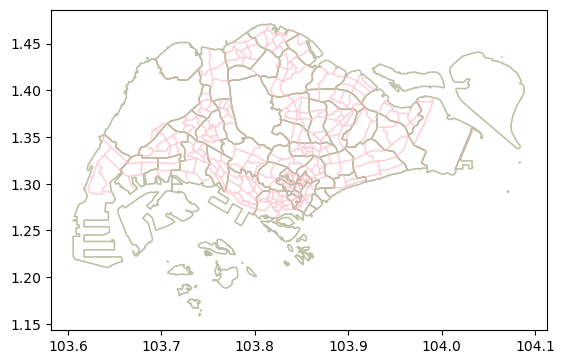

In [980]:
planningArea_shp = gpd.read_file(Data.PLANNING_AREA_FP)
subzone_shp = gpd.read_file(Data.SUBZONE_FP)
fig, ax = plt.subplots(1,1)
for shp,c in zip([planningArea_shp,subzone_shp],["green","pink"]):
    print(shp.columns)
    shp.plot(fc="none",ec=c,ax=ax,alpha=0.5)
plt.show()

## Import network

In [981]:
G_walk = ox.load_graphml(Data.G_WALK_FP)
G_car = ox.load_graphml(Data.G_CAR_FP)

## Import residential

Add spatial attributes

In [982]:
residential_df = Data.get_hdb_residential_df(Data.HDB_RESALE_RESIDENTIAL_FP)
print(f"Length of residential_df: {len(residential_df)}")
# drop duplicates where all content across columns are the same!
residential_df = residential_df.drop_duplicates(keep="first")
print(f"Length of residential_df after dropping duplicates: {len(residential_df)}")
# create a unique index that would identify each unique transaction so there is no need to keep quoting 5 column names to identify unique columns
residential_df['unique_index'] = residential_df[['Address','month_year','Transacted Price ($)','Area (SQM)','remaining_lease']].astype(str).apply(lambda x: ''.join(x), axis=1)
# add subzone
# spatial join with subzone, planning area and region
residential_df = residential_df.sjoin(subzone_shp[["SUBZONE_N","PLN_AREA_N",'REGION_N',"geometry"]],how="left")

# add nodesID for properties
residential_df['nodesID_property'] = ox.nearest_nodes(G_car,X=residential_df['LONGITUDE'], Y=residential_df['LATITUDE'])

print("length of residential df: ", len(residential_df))
# drop index_right
residential_df = residential_df.drop(columns=["index_right"])
print(f"Number of unique project name: {len(residential_df["Project Name"].unique())}")
print(f"Number of unique Address: {len(residential_df["Address"].unique())}")
print(f"Number of unique building name: {len(residential_df["Building Name"].unique())}")
print(f"Number of property types: {len(residential_df['Property Type'].unique())}")
print(f"Number of different floor number: {len(residential_df['Floor_level'].unique())}")
print(f"Number of ground floor units: {residential_df['is_ground_floor'].sum()}")
residential_df.head()


c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\data.py:93: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  resale_prices_df = pd.read_csv(fp)


Length of residential_df: 265007
Length of residential_df after dropping duplicates: 264453
length of residential df:  264453
Number of unique project name: 576
Number of unique Address: 46796
Number of unique building name: 9707
Number of property types: 7
Number of different floor number: 3
Number of ground floor units: 494


,month_year,town,Property Type,block,Project Name,Floor_level,Area (SQM),flat_model,lease_commence_date,Transacted Price ($),...,Building Age,Address,Sale_Date,is_ground_floor,geometry,unique_index,SUBZONE_N,PLN_AREA_N,REGION_N,nodesID_property
656847,2015-01,ANG MO KIO,3 ROOM,174,ANG MO KIO AVE 4,middle,60.0,premium/DBSS/Type S1/2,1986,255000.0,...,29.0,174 ANG MO KIO AVE 4 07 TO 09,2015-01-01,False,POINT (103.83946 1.37648),174 ANG MO KIO AVE 4 07 TO 092015-01255000.060...,KEBUN BAHRU,ANG MO KIO,NORTH-EAST REGION,231866450
656848,2015-01,ANG MO KIO,3 ROOM,541,ANG MO KIO AVE 10,low,68.0,generation/Model A,1981,275000.0,...,34.0,541 ANG MO KIO AVE 10 01 TO 03,2015-01-01,False,POINT (103.85659 1.36677),541 ANG MO KIO AVE 10 01 TO 032015-01275000.06...,CHONG BOON,ANG MO KIO,NORTH-EAST REGION,4614444680
656849,2015-01,ANG MO KIO,3 ROOM,163,ANG MO KIO AVE 4,low,69.0,generation/Model A,1980,285000.0,...,35.0,163 ANG MO KIO AVE 4 01 TO 03,2015-01-01,False,POINT (103.83946 1.37648),163 ANG MO KIO AVE 4 01 TO 032015-01285000.069...,KEBUN BAHRU,ANG MO KIO,NORTH-EAST REGION,231866450
656850,2015-01,ANG MO KIO,3 ROOM,446,ANG MO KIO AVE 10,low,68.0,generation/Model A,1979,290000.0,...,36.0,446 ANG MO KIO AVE 10 01 TO 03,2015-01-01,False,POINT (103.85659 1.36677),446 ANG MO KIO AVE 10 01 TO 032015-01290000.06...,CHONG BOON,ANG MO KIO,NORTH-EAST REGION,4614444680
656851,2015-01,ANG MO KIO,3 ROOM,557,ANG MO KIO AVE 10,middle,68.0,generation/Model A,1980,290000.0,...,35.0,557 ANG MO KIO AVE 10 07 TO 09,2015-01-01,False,POINT (103.85659 1.36677),557 ANG MO KIO AVE 10 07 TO 092015-01290000.06...,CHONG BOON,ANG MO KIO,NORTH-EAST REGION,4614444680


["Since 1969, the HDB has made a conscious decision to keep the ground floor of blocks free of housing units and only allow communal amenities such as kindergartens, childcare centres and senior citizens clubs."](https://www.nlb.gov.sg/main/article-detail?cmsuuid=e342b869-736c-4e4c-a346-47b164663572)

- A (Apartment/Area): Larger, better finishes (Model A), e.g., 3A, 4A, 5A.
- I (Improved): Mid-range, better than Simplified.
- S (Simplified): Basic, smaller. 

## Import flood data

In [983]:
# historical flood
flood_df = Data.get_flood_df(Data.FLOOD_FP)
# update frroms from 2013 to 2025
# spatial join with subzone
flood_df = flood_df.sjoin(subzone_shp[["SUBZONE_N","PLN_AREA_N","geometry"]],how="left")
flood_df.head()

,Flood_Date,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,flooded_location,geometry,index_right,SUBZONE_N,PLN_AREA_N
0,2013-01-02,58589 (BUS STOP),NaN,GAMBAS AVE,58589 (BUS STOP),58589 (BUS STOP),NIL,25757.985102,47244.565267,1.443537,103.813172,58589 (Bus stop),POINT (103.81317 1.44354),325,MANDAI EAST,MANDAI
1,2013-02-08,ONE COMMONWEALTH,1,COMMONWEALTH LANE,ONE COMMONWEALTH,1 COMMONWEALTH LANE ONE COMMONWEALTH SINGAPORE...,149544,23935.142214,31862.576376,1.304428,103.796794,One Commonwealth,POINT (103.79679 1.30443),226,HOLLAND DRIVE,QUEENSTOWN
2,2013-02-08,42059 (BUS STOP),NaN,DUNEARN RD,42059 (BUS STOP),42059 (BUS STOP),NIL,22373.582277,35402.855413,1.336445,103.782762,42059,POINT (103.78276 1.33644),152,SWISS CLUB,BUKIT TIMAH
3,2013-04-28,ANSAR GARDEN,26,CHAI CHEE ROAD,ANSAR GARDEN,26 CHAI CHEE ROAD ANSAR GARDEN SINGAPORE 460026,460026,38049.701026,33950.774561,1.323312,103.923620,Ansar Garden,POINT (103.92362 1.32331),148,KEMBANGAN,BEDOK
4,2013-09-05,34 JUBILEE ROAD SINGAPORE 128585,34,JUBILEE ROAD,NIL,34 JUBILEE ROAD SINGAPORE 128585,128585,20693.950961,32036.202702,1.305998,103.767670,34 Jubilee Rd,POINT (103.76767 1.306),59,CLEMENTI WOODS,CLEMENTI


## Import PUB-compiled flooding hotspot

In [984]:
flooding_hotspot_buffer = Data.get_flooding_hotspot_buffer(Data.FLOODING_HOTSPOT_FP, radius=buffer)
print("Earliest record of hotspot date:", flooding_hotspot_buffer["Flood_Hotspot_Date"].sort_values().values[0])
flooding_hotspot_buffer.head()

Earliest record of hotspot date: 2011-12-01T00:00:00.000000000


,Flood_Hotspot_Date,flooded_locations,responses_,matched_lo,LATITUDE,LONGITUDE,geometry,year,month
0,2017-07-01,52079 (BUS STOP),1,52079 (BUS STOP),1.329315,103.843829,"POLYGON ((103.84344 1.3339, 103.84358 1.33392,...",2017,7
1,2017-07-01,MAXWELL FOOD CENTRE,1,MAXWELL FOOD CENTRE,1.280331,103.844747,"POLYGON ((103.84097 1.27726, 103.84081 1.27742...",2017,7
2,2017-07-01,MOUNT PLEASANT FLYOVER,1,MOUNT PLEASANT FLYOVER,1.327126,103.826616,"POLYGON ((103.83131 1.32375, 103.8313 1.32357,...",2017,7
3,2017-07-01,Tiong Bahru Road,1,TIONG BAHRU ROAD,1.284881,103.834043,"POLYGON ((103.83083 1.28171, 103.83079 1.28176...",2017,7
4,2011-12-01,01419 (BUS STOP),1,01419 (BUS STOP),1.302020,103.863263,"POLYGON ((103.86226 1.30685, 103.86232 1.3069,...",2011,12


## Import area near the coast prone to flooding during high-tide (3m)

In [985]:
tide_3m_polygon = Data.get_coastal_flood_prone(Data.TIDE_3M_FP)
type(tide_3m_polygon)

shapely.geometry.multipolygon.MultiPolygon

## Import flood adaptation measures

- Compare downstream road raising + buffer analysis vs just road raising + buffer

### Import road raising buffer

In [986]:
road_raising_works_buffer_df = Data.get_road_raising_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                               buffer_dist=buffer)
road_raising_works_buffer_df.columns

Index(['S/N', 'Location', 'Drainage_Date', 'Status', 'year', 'month',
       'work_types', 'location', 'locations', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'number_of_searches', 'work_categories', 'u', 'v', 'key',
       'geometry'],
      dtype='object')

### Import downstream road raising network buffer

In [987]:
road_raising_network_buffer_df = Data.get_road_raising_network_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                                            reverse = False, 
                                                                            depth_limit = depth,
                                                                            buffer_dist=buffer)
fig, axes = plt.subplots(1,2,figsize=(10,6))
for ax,title in zip(axes.flatten(),["road_raising_works_buffer_df","road_raising_network_buffer_df"]):
    planningArea_shp.plot(fc="None",ec="k",alpha=0.8,ax=ax)
    road_raising_df = Data.get_road_raising_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,buffer_dist=None)
    road_raising_df.plot(ax=ax,color="red")
    ax.set_title(title)
    ax.axis('off')

road_raising_works_buffer_df.plot(ax=axes[0],color="green",alpha=0.5)
road_raising_network_buffer_df.plot(ax=axes[1],color="green",alpha=0.5)
plt.show()
road_raising_network_buffer_df.columns

GEOSException: bad allocation

### Import drainage works (within 500 m buffer)

In [ ]:
# includes both drainage works on roadside and outlet drains + culvert improvement works
drainage_works_df = Data.get_drain_improvement_buffer_df(G_car, Data.DRAINAGE_WORKS_FP, 
                                                         buffer_dist=buffer)
# drainage_works_df = Data.get_drainage_works_buffer_df(Data.DRAINAGE_WORKS_FP)
print("Type of works: ",drainage_works_df['work_categories'].unique())
drainage_works_df.columns

c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\data.py:259: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # get the gdfs of drains_df and culvert_df
c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\data.py:260: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drains_df = DrainageWork.get_drainage_works_gdf(G, drains_df)

Type of works:  ['Improvement to Roadside/Outlet Drains' 'Improvement to Culvert']


Index(['S/N', 'Location', 'Drainage_Date', 'Status', 'year', 'month',
       'work_types', 'location', 'locations', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'number_of_searches', 'work_categories', 'u', 'v', 'key',
       'geometry'],
      dtype='object')

### Combine road raising + drainage works df

Unique type of adaptation works:  ['Road Raising' 'Improvement to Roadside/Outlet Drains'
 'Improvement to Culvert']


,u,v,geometry,S/N,Location,Drainage_Date,Status,year,month,work_types,...,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches,work_categories,key
0,408735646,2641677416,"POLYGON ((103.84695 1.32519, 103.84689 1.32513...",2,Road Raising and Drainage Works at Ah Hood Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,...,NIL,AH HOOD ROAD,NIL,29506.53095,34437.90694,1.327719,103.846855,2.0,Road Raising,0
1,2168300378,6754998201,"POLYGON ((103.8329 1.31317, 103.83291 1.31315,...",3,Road Raising and Drainage Works at Balmoral Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,...,NIL,BALMORAL ROAD,NIL,27650.84321,32837.30661,1.313244,103.830181,1.0,Road Raising,0
2,1268263183,1268264187,"POLYGON ((103.94543 1.3298, 103.94515 1.33017,...",4,Road Raising and Drainage Works at Bedok Lane,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,...,NIL,BEDOK LANE,NIL,40790.72226,34619.56054,1.329357,103.948251,1.0,Road Raising,0
3,243486752,3030270542,"POLYGON ((103.95035 1.3232, 103.95037 1.32327,...",5,Road Raising and Drainage Works at Bedok Garden,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,...,NaN,NaN,NaN,NaN,NaN,1.322983,103.952932,3.0,Road Raising,0
4,3756077209,1744516916,"POLYGON ((103.82329 1.31753, 103.82329 1.31753...",6,Road Raising and Drainage Works at Lewis Rd,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,...,NIL,LEWIS ROAD,NIL,26819.60407,33600.97291,1.320150,103.822712,1.0,Road Raising,0


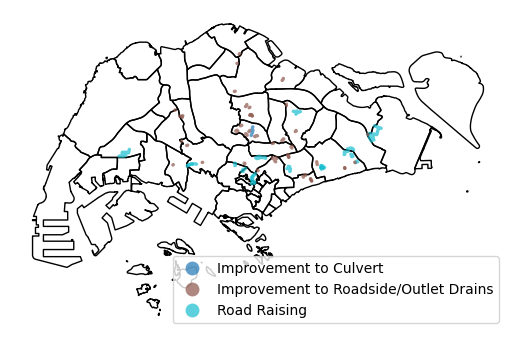

In [ ]:
if road_network_buffer: # ise use road net work buffer
    road_drainage_works = pd.concat([road_raising_network_buffer_df,drainage_works_df])
else:
    road_drainage_works = pd.concat([road_raising_works_buffer_df,drainage_works_df])
# convert to a geodataframe
road_drainage_works = gpd.GeoDataFrame(data=road_drainage_works, geometry=road_drainage_works['geometry'])
print("Unique type of adaptation works: ", road_drainage_works["work_categories"].unique())

# plot
ax = planningArea_shp.plot(fc="None",ec="k")
road_drainage_works.plot(column="work_categories",alpha=0.7,ax=ax,
                         figsize=(15, 10),
                         legend=True,
                         legend_kwds={'loc': 'lower right'})
ax.axis('off')
# plt.savefig(r"Exported_Data\exported_figures\drainage_works_consolidated.svg", bbox_inches='tight')
road_drainage_works.head()

## Import drainage density

In [ ]:
drainage_density_df = Data.get_drainage_density_df(Data.DRAINAGE_DENSITY_FP)
drainage_density_df.head()

,year_drainage_density,SUBZONE_N,drainage_length_km,area_km2,drainage_density (km/km2)
0,2008,DEPOT ROAD,0.141179,0.442297,0.319195
1,2008,BUKIT MERAH,1.312479,0.411723,3.187775
2,2008,CHINATOWN,0.000000,0.587223,0.000000
3,2008,PHILLIP,0.000000,0.039438,0.000000
4,2008,RAFFLES PLACE,0.000000,0.188767,0.000000


## Import residential attributes

### Distance to top primary schools

In [ ]:
# travel_time_school_car = Data.get_travel_time_to_schools(Data.PRI_SCH_CAR_TRAVEL_FP,suffix="car")
# travel_time_school_walk = Data.get_travel_time_to_schools(Data.PRI_SCH_WALK_TRAVEL_FP,suffix="walk")
# # only select within 1/2km and min distance
# travel_time_school_car = travel_time_school_car[["Address","Sale_Date"]+travel_time_school_car.columns[-3:].to_list()]
# travel_time_school_walk = travel_time_school_walk[["Address","Sale_Date"]+travel_time_school_walk.columns[-3:].to_list()]
# travel_time_school_walk.head()

### Workplace cluster

In [ ]:
# workplace_cluster_df = Data.get_workplace_cluster(G_car,Data.WORKPLACE_CLUSTER_FP)
# workplace_cluster_df.head()

In [ ]:
# travel_time_work_cluster = residential_attributes.get_travel_time_to_destination(G_car,residential_df,residential_nodes_column_name='nodesID_property',
#                                                       destination_df=workplace_cluster_df[workplace_cluster_df['PLN_AREA_N'].isin(['DOWNTOWN CORE','TAMPINES','JURONG EAST','ANG MO KIO', 'WOODLANDS'])],
#                                                       destination_nodes_column_name="node_ID")
# travel_time_work_cluster

### Malls

In [ ]:
malls_df = Data.get_mall_df(Data.MALLS_FP)
malls_df.head()

,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,Mall Name,nodesID_car_mall,nodesID_walk_mall,geometry
0,ALEXANDRA RETAIL CENTRE (ARC),460,ALEXANDRA ROAD,ALEXANDRA RETAIL CENTRE (ARC),460 ALEXANDRA ROAD ALEXANDRA RETAIL CENTRE (AR...,119963,24447.647553565,28514.458416285,1.274149,103.801399,Alexandra Retail Centre,435833857,5269394155,POINT (103.8014 1.27415)
1,AMK HUB,53,ANG MO KIO AVENUE 3,AMK HUB,53 ANG MO KIO AVENUE 3 AMK HUB SINGAPORE 569933,569933,29687.0565410079,39045.6241728477,1.369389,103.848478,AMK Hub,435824984,4540628535,POINT (103.84848 1.36939)
2,BEDOK MALL,311,NEW UPPER CHANGI ROAD,BEDOK MALL,311 NEW UPPER CHANGI ROAD BEDOK MALL SINGAPORE...,467360,38676.9034392368,34108.3360637221,1.324736,103.929256,Bedok Mall,4675722406,8982593125,POINT (103.92926 1.32474)
3,BUGIS JUNCTION,200,VICTORIA STREET,BUGIS JUNCTION,200 VICTORIA STREET BUGIS JUNCTION SINGAPORE 1...,188021,30458.7085178969,31274.8305191435,1.299113,103.855411,Bugis Junction,232119579,4755817437,POINT (103.85541 1.29911)
4,BUGIS CUBE,470,NORTH BRIDGE ROAD,BUGIS CUBE,470 NORTH BRIDGE ROAD BUGIS CUBE SINGAPORE 188735,188735,30483.6570850834,31167.3475166354,1.298141,103.855635,Bugis+,232119579,11037228265,POINT (103.85564 1.29814)


### Parks

In [ ]:
parks_df = Data.get_park_df(Data.PARKS_FP)
parks_df.head()

,FID,N_RESERVE,L_CODE,NAME,Shape_Leng,Shape_Area,geometry
0,0,1,NRNP01,LABRADOR NATURE RESERVE,1817.143003,1.005354e+05,"POLYGON ((103.80273 1.26782, 103.80276 1.26783..."
1,1,1,NRNP03,BUKIT TIMAH NATURE RESERVE,7747.590684,1.623659e+06,"POLYGON ((103.77687 1.36072, 103.77693 1.36103..."
2,2,1,NRNP05,UPPER SELETAR RESERVOIR PARK,3625.555022,1.344146e+05,"POLYGON ((103.80826 1.40542, 103.80811 1.4055,..."
3,3,1,NRNP06,UPPER PEIRCE RESERVOIR PARK,1523.955588,6.916462e+04,"POLYGON ((103.81347 1.37173, 103.81331 1.37201..."
4,4,0,NRNP08,THOMSON NATURE PARK,4263.882120,5.117329e+05,"POLYGON ((103.82141 1.38599, 103.82134 1.38603..."


### MRT (within 400m buffer)

In [ ]:
mrt_buffer_df = Data.get_MRT_buffer_df(Data.MRT_FP, buffer_dist=buffer)
mrt_buffer_df.head()

,mrt_code,stn_name,opening_date,year,month,interchange_number,mrt_line,stn_code,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,geometry
0,NS10,ADMIRALTY MRT STATION,1996-02-10,1996.0,2.0,1.0,NS,NS10,ADMIRALTY MRT STATION (NS10),70,WOODLANDS AVENUE 7,ADMIRALTY MRT STATION (NS10),70 WOODLANDS AVENUE 7 ADMIRALTY MRT STATION (N...,738344,24402.386627,46918.506802,1.440589,103.800991,"POLYGON ((103.80279 1.44059, 103.80278 1.44041..."
1,EW9,ALJUNIED MRT STATION,1989-11-04,1989.0,11.0,1.0,EW,EW9,ALJUNIED MRT STATION (EW9),81,LORONG 25 GEYLANG,ALJUNIED MRT STATION (EW9),81 LORONG 25 GEYLANG ALJUNIED MRT STATION (EW9...,388310,33518.604869,33190.002017,1.316433,103.882906,"POLYGON ((103.8847 1.31643, 103.88469 1.31626,..."
3,NS16 CR11,ANG MO KIO MRT STATION,1987-11-07,1987.0,11.0,1.0,NS,NS16,ANG MO KIO MRT STATION (NS16),2795,ANG MO KIO AVENUE 8,ANG MO KIO MRT STATION (NS16),2795 ANG MO KIO AVENUE 8 ANG MO KIO MRT STATIO...,569812,29807.261147,39105.735995,1.369933,103.849558,"POLYGON ((103.85135 1.36993, 103.85135 1.36976..."
4,SE3,BAKAU LRT STATION,2003-01-18,2003.0,1.0,1.0,SE,SE3,BAKAU LRT STATION (SE3),50,RIVERVALE DRIVE,BAKAU LRT STATION (SE3),50 RIVERVALE DRIVE BAKAU LRT STATION (SE3) SIN...,545053,36023.433345,41102.996687,1.387994,103.905415,"POLYGON ((103.90721 1.38799, 103.9072 1.38782,..."
5,BP9,BANGKIT LRT STATION,1999-11-06,1999.0,11.0,1.0,BP,BP9,BANGKIT LRT STATION (BP9),20,BUKIT PANJANG RING ROAD,BANGKIT LRT STATION (BP9),20 BUKIT PANJANG RING ROAD BANGKIT LRT STATION...,679939,21248.056588,40221.448411,1.380022,103.772647,"POLYGON ((103.77444 1.38002, 103.77444 1.37984..."


# Merge all datasets

## Initialise master df

In [ ]:
master_df = copy.deepcopy(residential_df)
# # get floor number for high rises only
# master_df['Floor_level'] = master_df.apply(lambda x: residential_attributes.get_floor_number(x),axis=1)
# # for NA values in flood level, replace NA with 0 because they are usually landed properties
# master_df['Floor_level'] = master_df['Floor_level'].fillna(value=0)
# # create binary variable for ground floor
# master_df['is_ground_floor'] = master_df.apply(lambda x: residential_attributes.get_ground_floor(x), axis=1)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['month_year', 'town', 'Property Type', 'block', 'Project Name',
       'Floor_level', 'Area (SQM)', 'flat_model', 'lease_commence_date',
       'Transacted Price ($)', 'remaining_lease', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Name', 'Building Age',
       'Address', 'Sale_Date', 'is_ground_floor', 'geometry', 'unique_index',
       'SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'nodesID_property'],
      dtype='object')
length of df:  264453


## Merge with travel time to top 5 workplace cluster

In [ ]:
# master_df = master_df.merge(travel_time_work_cluster)
# print(master_df.columns)
# print("length of df: ", len(master_df))

## Merge with travel time to top primary schools

In [ ]:
# master_df = reduce(lambda  left,right: pd.merge(left,right,how="left",on=["Address","Sale_Date"]),[master_df,travel_time_school_car,travel_time_school_walk])
# print(master_df.columns)
# print("length of df: ", len(master_df))

## Merge with centrality metrics

In [ ]:
master_df = residential_attributes.add_centrality_metrics(master_df,residential_nodes_column_name='nodesID_property',
                                                          standardise=True)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['month_year', 'town', 'Property Type', 'block', 'Project Name',
       'Floor_level', 'Area (SQM)', 'flat_model', 'lease_commence_date',
       'Transacted Price ($)', 'remaining_lease', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Name', 'Building Age',
       'Address', 'Sale_Date', 'is_ground_floor', 'geometry', 'unique_index',
       'SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'nodesID_property',
       'betweeness_centrality', 'closeness_centrality'],
      dtype='object')
length of df:  264453


## Merge with malls

In [ ]:
# create buffer aorund malls (points)
mall_buffer_df = residential_attributes.get_malls(G_walk,malls_df,radius=buffer,plot=False)
master_df = residential_attributes.add_malls(master_df,mall_buffer_df,groupby_columns = ['Project Name','Address','Sale_Date'])
print(master_df.columns)
print("length of df: ", len(master_df))

6373456776: Number of nodes less than 2: 1
Index(['month_year', 'town', 'Property Type', 'block', 'Project Name',
       'Floor_level', 'Area (SQM)', 'flat_model', 'lease_commence_date',
       'Transacted Price ($)', 'remaining_lease', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Name', 'Building Age',
       'Address', 'Sale_Date', 'is_ground_floor', 'geometry', 'unique_index',
       'SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'nodesID_property',
       'betweeness_centrality', 'closeness_centrality', 'malls within 400m'],
      dtype='object')
length of df:  264453


## Merge with parks

In [ ]:
master_df = residential_attributes.add_parks(master_df, parks_df, radius=buffer, plot=False)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['month_year', 'town', 'Property Type', 'block', 'Project Name',
       'Floor_level', 'Area (SQM)', 'flat_model', 'lease_commence_date',
       'Transacted Price ($)', 'remaining_lease', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Name', 'Building Age',
       'Address', 'Sale_Date', 'is_ground_floor', 'geometry', 'unique_index',
       'SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'nodesID_property',
       'betweeness_centrality', 'closeness_centrality', 'malls within 400m',
       'parks within 400m'],
      dtype='object')
length of df:  264453


## Merge with MRT

In [ ]:
master_df = mrt_buffer.add_mrt_buffer(master_df,mrt_buffer_df,
                              address_column = "Address", sale_date_column = "Sale_Date",
                                construction_period = 6)
print(master_df.columns)
print("length of df: ", len(master_df))

length of df after spatial joining residential and train df:  265801
length of train df:  254901
length of df after merging residential and train df:  264453
Index(['month_year', 'town', 'Property Type', 'block', 'Project Name',
       'Floor_level', 'Area (SQM)', 'flat_model', 'lease_commence_date',
       'Transacted Price ($)', 'remaining_lease', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Name', 'Building Age',
       'Address', 'Sale_Date', 'is_ground_floor', 'geometry', 'unique_index',
       'SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'nodesID_property',
       'betweeness_centrality', 'closeness_centrality', 'malls within 400m',
       'parks within 400m', 'existing_stn_count', 'upcoming_stn_count',
       'stn_lines'],
      dtype='object')
length of df:  264453


## Merge with DEM

In [ ]:
master_df["DEM"] = master_df.apply(lambda x: DEM.get_DEM_value(x["LONGITUDE"],x["LATITUDE"]),axis=1)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['month_year', 'town', 'Property Type', 'block', 'Project Name',
       'Floor_level', 'Area (SQM)', 'flat_model', 'lease_commence_date',
       'Transacted Price ($)', 'remaining_lease', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Name', 'Building Age',
       'Address', 'Sale_Date', 'is_ground_floor', 'geometry', 'unique_index',
       'SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'nodesID_property',
       'betweeness_centrality', 'closeness_centrality', 'malls within 400m',
       'parks within 400m', 'existing_stn_count', 'upcoming_stn_count',
       'stn_lines', 'DEM'],
      dtype='object')
length of df:  264453


## Merge with flood event

- Use 6/12/18 months to flag transaction records that has floods occurring within 6/12/18 months
- Include continuous weeks-since-flood as robustness checks (*Note: this is added after checking whether location is in a flood prone area as a check to see if the area has experienced repeated flooding. Reduce noise in dataset by only examining areas with repeated flooding)

In [ ]:
master_df = master_df.merge(flood_df[["flooded_location","Flood_Date","SUBZONE_N"]],how="left",
                    left_on=["SUBZONE_N",'Sale_Date'], 
                    right_on=["SUBZONE_N",'Flood_Date'],suffixes=('_property','_flood'))
# master_df = master_df.drop_duplicates(subset=['Project Name','Address','Sale_Date'])
master_df = master_df.drop_duplicates(subset=['unique_index'])
master_df = Flood.add_flood_within_months(master_df,sale_date_column="Sale_Date",months_after_flood=6,
                                          groupby_column=["SUBZONE_N"],
                                          drop_duplicate_column=["unique_index"])
master_df = Flood.add_flood_within_months(master_df,sale_date_column="Sale_Date",months_after_flood=12,
                                          groupby_column=["SUBZONE_N"],
                                          drop_duplicate_column=["unique_index"])
master_df = Flood.add_flood_within_months(master_df,sale_date_column="Sale_Date",months_after_flood=18,
                                          groupby_column=["SUBZONE_N"],
                                          drop_duplicate_column=["unique_index"])
master_df = Flood.add_weeks_since_flood(master_df,sale_date_column="Sale_Date", 
                                          groupby_column=["SUBZONE_N"],
                                          drop_duplicate_column=["unique_index"],
                                          fillna=np.nan)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['month_year', 'town', 'Property Type', 'block', 'Project Name',
       'Floor_level', 'Area (SQM)', 'flat_model', 'lease_commence_date',
       'Transacted Price ($)', 'remaining_lease', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Name', 'Building Age',
       'Address', 'Sale_Date', 'is_ground_floor', 'geometry', 'unique_index',
       'SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'nodesID_property',
       'betweeness_centrality', 'closeness_centrality', 'malls within 400m',
       'parks within 400m', 'existing_stn_count', 'upcoming_stn_count',
       'stn_lines', 'DEM', 'flooded_location', 'Flood_Date',
       'within_6_months_post_flood', 'within_12_months_post_flood',
       'within_18_months_post_flood', 'weeks_since_flood'],
      dtype='object')
length of df:  264453


## Merge with PUB-compiled flooding hotspot
- Identifies if an area is within a flood prone area for that transaction year
    - if publication date of the flooding hotspot is after the transaction date, it means the location is in a flood prone area
- Obtain the latest flooding hotspot date
- Directly examine whether flood occurs in a flood-prone area or not, and if flood recency has an impact on property price for area that is flood-prone and for area that is not flood-prone

In [ ]:
master_df = Flood.add_within_flooding_hotspot_buffer(master_df,flooding_hotspot_buffer,
                                                    #  groupby_column = ["Project Name"], 
                                                    groupby_column=[adaptation_groupby_column],
                                                     sale_date_column="Sale_Date")
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['month_year', 'town', 'Property Type', 'block', 'Project Name',
       'Floor_level', 'Area (SQM)', 'flat_model', 'lease_commence_date',
       'Transacted Price ($)', 'remaining_lease', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Name', 'Building Age',
       'Address', 'Sale_Date', 'is_ground_floor', 'geometry', 'unique_index',
       'SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'nodesID_property',
       'betweeness_centrality', 'closeness_centrality', 'malls within 400m',
       'parks within 400m', 'existing_stn_count', 'upcoming_stn_count',
       'stn_lines', 'DEM', 'flooded_location', 'Flood_Date',
       'within_6_months_post_flood', 'within_12_months_post_flood',
       'within_18_months_post_flood', 'weeks_since_flood',
       'latest_flooding_hotspot_date', 'within_flooding_hotspot'],
      dtype='object')
length of df:  264453


## Merge with coastal flood prone area

In [ ]:
master_df["prone_to_high_tide"] = master_df['geometry'].apply(lambda x: tide_3m_polygon.intersects(x))
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['month_year', 'town', 'Property Type', 'block', 'Project Name',
       'Floor_level', 'Area (SQM)', 'flat_model', 'lease_commence_date',
       'Transacted Price ($)', 'remaining_lease', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Name', 'Building Age',
       'Address', 'Sale_Date', 'is_ground_floor', 'geometry', 'unique_index',
       'SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'nodesID_property',
       'betweeness_centrality', 'closeness_centrality', 'malls within 400m',
       'parks within 400m', 'existing_stn_count', 'upcoming_stn_count',
       'stn_lines', 'DEM', 'flooded_location', 'Flood_Date',
       'within_6_months_post_flood', 'within_12_months_post_flood',
       'within_18_months_post_flood', 'weeks_since_flood',
       'latest_flooding_hotspot_date', 'within_flooding_hotspot',
       'prone_to_high_tide'],
      dtype='object')
length of df:  264453


## Merge with drainage work type

In [ ]:
print(sorted(drainage_works_df.columns))
print(sorted(road_drainage_works.columns))

['ADDRESS', 'BLK_NO', 'BUILDING', 'Drainage_Date', 'LATITUDE', 'LONGITUDE', 'Location', 'POSTAL', 'ROAD_NAME', 'S/N', 'SEARCHVAL', 'Status', 'X', 'Y', 'geometry', 'key', 'location', 'locations', 'month', 'number_of_searches', 'u', 'v', 'work_categories', 'work_types', 'year']
['ADDRESS', 'BLK_NO', 'BUILDING', 'Drainage_Date', 'LATITUDE', 'LONGITUDE', 'Location', 'POSTAL', 'ROAD_NAME', 'S/N', 'SEARCHVAL', 'Status', 'X', 'Y', 'geometry', 'key', 'location', 'locations', 'month', 'number_of_searches', 'u', 'v', 'work_categories', 'work_types', 'year']


In [ ]:
# spatial join drainage works with master_df - this will produce duplicated rows because different drianage work categories can intersect with the same residential location at the same time
#  (i.e. multiple works carried out simultaneously at the same location)
master_drainage_df = master_df.sjoin(road_drainage_works[["work_categories","year","month","ROAD_NAME","geometry"]],how="left",
                                                        rsuffix="drainage",lsuffix="property",on_attribute=["year","month"])

print("length of df before merging: ", len(master_drainage_df))
print("Number of unique work categories: ", master_drainage_df['work_categories'].unique())
print(master_drainage_df['work_categories'].value_counts())
# aggregate drainage works by the same location e.g. work A and B are carried out at the same location but exists as separate rows in the df, 
# aggregate them such that it shows A & B works in one row instead of 2 row
master_df = master_df.merge(master_drainage_df.groupby(['unique_index']).agg({'work_categories': lambda x: ','.join([str(i) for i in set(x.tolist())])}).reset_index(level=[0]),
        on=['unique_index'])
# after aggregating work categories, the NaNs will join to become a string - nan, and it would read as a string instead of dtype==np.nan
master_df['work_categories'] = master_df['work_categories'].replace({"nan":np.nan})
print("length of df after merging: ", len(master_df))
print("Number of unique work categories: ", master_df['work_categories'].unique())
print(master_df['work_categories'].value_counts())



length of df before merging:  264453
Number of unique work categories:  [nan 'Improvement to Roadside/Outlet Drains' 'Road Raising']
work_categories
Road Raising                             43
Improvement to Roadside/Outlet Drains     8
Name: count, dtype: int64
length of df after merging:  264453
Number of unique work categories:  [nan 'Improvement to Roadside/Outlet Drains' 'Road Raising']
work_categories
Road Raising                             43
Improvement to Roadside/Outlet Drains     8
Name: count, dtype: int64


## Merge with drainage period

Identify if drainage work took place before and after Sale Date

In [ ]:
master_df = drainage_work.add_drainage_period(master_df, construction_period=0,
                                              groupby_column=[adaptation_groupby_column])
# replace construction with before
master_df['drainage_period'] = master_df['drainage_period'].apply(lambda x: "before" if x=="construction" else x)
# master_df = master_df.sjoin(road_drainage_works[["work_categories","year","month","ROAD_NAME","geometry"]],how="left",
#                                                         rsuffix="drainage",lsuffix="property",on_attribute=["year","month"])
# # remove duplicated index
# master_df = master_df[~master_df.index.duplicated(keep="first")]
# master_df = master_df.drop(columns=['index_drainage'])
# master_df = drainage_work.add_drainage_period(master_df, construction_period=0,
#                                               groupby_column=["Project Name"])
# # replace construction with before
# master_df['drainage_period'] = master_df['drainage_period'].apply(lambda x: "before" if x=="construction" else x)
print(master_df.columns)
print("length of df: ", len(master_df))
print("Number of unique work categories: ", master_df['work_categories'].unique())
print(master_df['work_categories'].value_counts())
# master_df = master_df.sjoin(drainage_works_df[["work_categ","year","month","ROAD_NAME","geometry"]],how="left",
#                                                         rsuffix="drainage",lsuffix="property",on_attribute=["year","month"])
# # remove duplicated index
# master_df = master_df[~master_df.index.duplicated(keep="first")]
# master_df = master_df.drop(columns=['index_drainage'])
# master_df = drainage_work.add_drainage_period(master_df, construction_period=6)
# print(master_df.columns)
# print("length of df: ", len(master_df))

c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\drainage_work.py:125: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  


Index(['month_year', 'town', 'Property Type', 'block', 'Project Name',
       'Floor_level', 'Area (SQM)', 'flat_model', 'lease_commence_date',
       'Transacted Price ($)', 'remaining_lease', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Name', 'Building Age',
       'Address', 'Sale_Date', 'is_ground_floor', 'geometry', 'unique_index',
       'SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'nodesID_property',
       'betweeness_centrality', 'closeness_centrality', 'malls within 400m',
       'parks within 400m', 'existing_stn_count', 'upcoming_stn_count',
       'stn_lines', 'DEM', 'flooded_location', 'Flood_Date',
       'within_6_months_post_flood', 'within_12_months_post_flood',
       'within_18_months_post_flood', 'weeks_since_flood',
       'latest_flooding_hotspot_date', 'within_flooding_hotspot',
       'prone_to_high_tide', 'work_categories', 'drainage_period'],
      dtype='object')
l

## Merge with drainage density

In [ ]:
master_df = master_df.merge(drainage_density_df,how="left",left_on=["SUBZONE_N","year"],right_on=["SUBZONE_N","year_drainage_density"])
master_df = drainage_work.add_drainage_density(master_df,drainage_density_df,sale_date_column = "Sale_Date",noData=0,
                                               groupby_column=["SUBZONE_N"])
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['month_year', 'town', 'Property Type', 'block', 'Project Name',
       'Floor_level', 'Area (SQM)', 'flat_model', 'lease_commence_date',
       'Transacted Price ($)', 'remaining_lease', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Name', 'Building Age',
       'Address', 'Sale_Date', 'is_ground_floor', 'geometry', 'unique_index',
       'SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'nodesID_property',
       'betweeness_centrality', 'closeness_centrality', 'malls within 400m',
       'parks within 400m', 'existing_stn_count', 'upcoming_stn_count',
       'stn_lines', 'DEM', 'flooded_location', 'Flood_Date',
       'within_6_months_post_flood', 'within_12_months_post_flood',
       'within_18_months_post_flood', 'weeks_since_flood',
       'latest_flooding_hotspot_date', 'within_flooding_hotspot',
       'prone_to_high_tide', 'work_categories', 'drainage_period',
       'year_drainage_de

# Simplify data

In [ ]:
# only keep relevant columns in master_df

columns_unkeep = ['town','block',"lease_commence_date",'remaining_lease','SEARCHVAL', 'BLK_NO',
       'POSTAL', 'X', 'Y','BUILDING',
       'LATITUDE', 'LONGITUDE', 'geometry','nodesID_property','year_drainage_density',
       'drainage_length_km', 'area_km2','flooded_location','Flood_Date',"latest_flooding_hotspot_date"]
master_df_minimal =  master_df.drop(columns = columns_unkeep)
# rename columns for readability in R
rename_columns = {c: re.sub(r"\s|/","_",c) for c in master_df_minimal.columns}
master_df_minimal = master_df_minimal.rename(columns = rename_columns)
print(master_df_minimal.columns)
print("length of df: ", len(master_df_minimal))
master_df_minimal.head()

Index(['month_year', 'Property_Type', 'Project_Name', 'Floor_level',
       'Area_(SQM)', 'flat_model', 'Transacted_Price_($)', 'ROAD_NAME',
       'ADDRESS', 'year', 'month', 'Building_Name', 'Building_Age', 'Address',
       'Sale_Date', 'is_ground_floor', 'unique_index', 'SUBZONE_N',
       'PLN_AREA_N', 'REGION_N', 'betweeness_centrality',
       'closeness_centrality', 'malls_within_400m', 'parks_within_400m',
       'existing_stn_count', 'upcoming_stn_count', 'stn_lines', 'DEM',
       'within_6_months_post_flood', 'within_12_months_post_flood',
       'within_18_months_post_flood', 'weeks_since_flood',
       'within_flooding_hotspot', 'prone_to_high_tide', 'work_categories',
       'drainage_period', 'drainage_density_(km_km2)'],
      dtype='object')
length of df:  264453


,month_year,Property_Type,Project_Name,Floor_level,Area_(SQM),flat_model,Transacted_Price_($),ROAD_NAME,ADDRESS,year,...,DEM,within_6_months_post_flood,within_12_months_post_flood,within_18_months_post_flood,weeks_since_flood,within_flooding_hotspot,prone_to_high_tide,work_categories,drainage_period,drainage_density_(km_km2)
0,2015-01,3 ROOM,ANG MO KIO AVE 4,middle,60.0,premium/DBSS/Type S1/2,255000.0,ANG MO KIO AVENUE 4,ANG MO KIO AVENUE 4,2015,...,14.67,False,False,False,107.0,False,False,none,never,0.104371
1,2015-01,3 ROOM,ANG MO KIO AVE 10,low,68.0,generation/Model A,275000.0,ANG MO KIO AVENUE 10,ANG MO KIO AVENUE 10,2015,...,22.42,False,False,False,107.0,False,False,none,never,0.104371
2,2015-01,3 ROOM,ANG MO KIO AVE 4,low,69.0,generation/Model A,285000.0,ANG MO KIO AVENUE 4,ANG MO KIO AVENUE 4,2015,...,14.67,False,False,False,107.0,False,False,none,never,0.104371
3,2015-01,3 ROOM,ANG MO KIO AVE 10,low,68.0,generation/Model A,290000.0,ANG MO KIO AVENUE 10,ANG MO KIO AVENUE 10,2015,...,22.42,False,False,False,107.0,False,False,none,never,0.104371
4,2015-01,3 ROOM,ANG MO KIO AVE 10,middle,68.0,generation/Model A,290000.0,ANG MO KIO AVENUE 10,ANG MO KIO AVENUE 10,2015,...,22.42,False,False,False,107.0,False,False,none,never,0.104371


# Export data

In [ ]:
master_df_minimal.to_csv(save_fp,index=False)

# Data cleaning of resale flat prices

In [ ]:
# resale_prices_dir = r"Data\ResaleFlatPrices"
# resale_prices_fps = [os.path.join(resale_prices_dir,fp) for fp in os.listdir(resale_prices_dir)]

In [ ]:
# resale_prices_df = pd.concat([pd.read_csv(fp) for fp in resale_prices_fps])
# print(f"length of df: {len(resale_prices_df)}")
# resale_prices_df.head()

In [ ]:
# print(len(resale_prices_df["street_name"].unique()))
# headers = OneMapAPI.generate_OneMap_headers()
# response = OneMapAPI.get_coordinates_from_location(resale_prices_df["street_name"].values[0],headers)
# new_headers = list(response)
# new_headers

# def postal_to_coord(row,column_names,headers):
#     try:
#         searchVal = OneMapAPI.get_coordinates_from_location(row,headers)
#     except:
#         searchVal = {c:np.nan for c in column_names}
#     searchVal["street_name"] = row
#     return pd.Series(searchVal,index=list(searchVal))

# resale_proj_name_searchVal = pd.Series(resale_prices_df["street_name"].unique()).apply(lambda x: postal_to_coord(x, new_headers,headers))
# print(len(resale_proj_name_searchVal))
# resale_proj_name_searchVal.head()

In [ ]:
# resale_prices_df = pd.merge(resale_prices_df,resale_proj_name_searchVal,how="inner",
#          on="street_name")
# print(f"length of df: {len(resale_prices_df)}")
# resale_prices_df.head()

In [ ]:
# save_dir = os.path.join(os.getcwd(),"Exported_Data")
# if not os.path.exists(save_dir):
#     os.mkdir(save_dir)
# resale_prices_df.to_csv(os.path.join(save_dir,"Resale_prices_2014_2024.csv"),index=False)